# Stage 2 — LSTM Misconception Classifier

**AAI-590 Capstone · Monish Yarapathineni**

Trains an LSTM from scratch to predict misconception categories per interaction
from a student's sequential history, against a context-free baseline that sees
only the current interaction.

**That comparison is the hypothesis.** The project claims misconception type is
legible from sequential *pattern* rather than from an isolated wrong answer.
Notebook 04 established the first half empirically — a single wrong answer
supports only κ ≈ 0.675 labeling agreement even for a strong model, because
several explanations fit the same observation. If sequence context carries the
extra signal, the LSTM beats the baseline. If it does not, the thesis fails, and
that is a real result either way.

---

### Design, settled in notebooks 02–05

| Decision | Value | Source |
|---|---|---|
| Target | Per-interaction **multi-label**, 8 categories | nb 04, macro κ 0.675 |
| Output head | 8 sigmoid units | multi-label |
| Loss | Masked BCE-with-logits, `pos_weight` per category | class imbalance |
| Unlabeled rows | **Masked**, not dropped | retain behavioural context |
| Split | By **student**, never by interaction | prevents leakage |
| Sequence unit | One student = one sequence | design doc |

**Masking matters.** Roughly 35–37% of misconception rows carry no label —
select-all problems and the fill-in tail beyond the top 10. Those timesteps stay
in the sequence so the LSTM sees the student attempted the problem, got it wrong,
used two hints — they just contribute no gradient.

### Scope

Runs on whatever labels exist. Partial labels from notebook 04 are enough to
verify the pipeline end to end; swap in the full file from notebook 05 and
retrain without changing any code.

---

## 1 · Setup

In [1]:
try:
    import google.colab
    IN_COLAB = True
    %pip install -q datasets huggingface_hub torch
except ImportError:
    IN_COLAB = False

import os, re, json, time, math, random
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, load_from_disk

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (9, 4)})

SEED = 590
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = ('cuda' if torch.cuda.is_available()
          else 'mps' if torch.backends.mps.is_available() else 'cpu')

# ---- Tunables --------------------------------------------------------------
MAX_LEN     = 350      # notebook 01: sequences run 215-421, mean 351
KC_EMB      = 32
HIDDEN      = 128
LAYERS      = 2
DROPOUT     = 0.2
LR          = 1e-3
EPOCHS      = 60
BATCH       = 32
PATIENCE    = 5

print(f"torch {torch.__version__} | device {DEVICE}")

torch 2.11.0+cu128 | device cuda


## 2 · Load labels

Accepts either the full run output (`misconception_labels_v1.json`, notebook 05)
or the pilot checkpoint (`stage1b_labels_checkpoint.json`, notebook 04). Coverage
is reported so you know which you are working with.

In [2]:
LABEL_CANDIDATES = [
    "misconception_labels_v1.json",
    "/content/drive/MyDrive/aai590/misconception_labels_v1.json",
    "stage1b_full_labels.json",
    "/content/drive/MyDrive/aai590/stage1b_full_labels.json",
    "stage1b_labels_checkpoint.json",
    "/content/drive/MyDrive/aai590/stage1b_labels_checkpoint.json",
]

LABEL_PATH = next((p for p in LABEL_CANDIDATES if os.path.exists(p)), None)
if LABEL_PATH is None and IN_COLAB:
    from google.colab import files
    print("Upload a label file (from notebook 04 or 05):")
    up = files.upload()
    LABEL_PATH = list(up.keys())[0]

with open(LABEL_PATH) as f:
    lab_raw = json.load(f)


def load_pair_labels(raw):
    """Accepts all three on-disk shapes. Detection is on record structure,
    not just the presence of a 'records' key -- notebook 04 and notebook 05
    both use that key with different schemas."""
    out = {}

    if isinstance(raw.get("records"), list) and raw["records"]:
        first = raw["records"][0]

        if "problem_id" in first:                    # notebook 05 output
            fmt = "notebook 05 output"
            for r in raw["records"]:
                out[(int(r["problem_id"]), str(r["wrong"]))] = r.get("labels", [])

        elif "pair" in first:                        # notebook 04 checkpoint
            fmt = "notebook 04 checkpoint"
            for r in raw["records"]:
                pid, wrong = r["pair"]
                out[(int(pid), str(wrong))] = r.get("labels", [])

        else:
            raise ValueError(f"Unrecognised record schema: {list(first)}")

    elif isinstance(raw.get("labels"), dict):        # notebook 05 checkpoint
        fmt = "notebook 05 checkpoint"
        for k, v in raw["labels"].items():
            pid, _, wrong = str(k).partition("||")
            out[(int(pid), wrong)] = v

    else:
        raise ValueError(f"Unrecognised label file; top-level keys: {list(raw)}")

    return out, fmt


pair_labels, detected = load_pair_labels(lab_raw)
pair_labels = {k: v for k, v in pair_labels.items() if v}   # drop empties

# Category order: sorted alphabetically so the target-vector index mapping is
# identical whichever label file is used. Saved with the model checkpoint.
seen = set()
for v in pair_labels.values():
    seen.update(x for x in v if x != "UNASSIGNABLE")
category_names = sorted(seen)
N_CAT = len(category_names)

print(f"Source  : {LABEL_PATH}")
print(f"Format  : {detected}")
print(f"Pairs   : {len(pair_labels):,}")
print(f"Mean labels per pair : {np.mean([len(v) for v in pair_labels.values()]):.2f}")
print(f"\n{N_CAT} categories:")
for i, c in enumerate(category_names):
    n = sum(1 for v in pair_labels.values() if c in v)
    print(f"  [{i}] {c:<38} {n:>6,} pairs")

Upload a label file (from notebook 04 or 05):


Saving misconception_labels_v1.json to misconception_labels_v1.json
Source  : misconception_labels_v1.json
Format  : notebook 05 output
Pairs   : 20,585
Mean labels per pair : 1.51

8 categories:
  [0] Appearance-Based Spatial Reasoning        611 pairs
  [1] Conceptual Meaning Error                5,038 pairs
  [2] Corrupted Procedure Execution          10,297 pairs
  [3] Faulty Fact or Formula Recall           3,757 pairs
  [4] Invalid Rule Generalisation             2,689 pairs
  [5] Representation Misreading               2,234 pairs
  [6] Task Interpretation & Monitoring        3,966 pairs
  [7] Terminology & Notation Confusion        2,031 pairs


## 3 · Load FoundationalASSIST

In [3]:
if IN_COLAB:
    from huggingface_hub import login
    login()

HF_REPO = 'ASSISTments/FoundationalASSIST'
LOCAL_BASE = os.path.expanduser('~/Desktop/Educator/aai590-capstone/data/foundationalassist')

if IN_COLAB:
    problems     = load_dataset(HF_REPO, 'Foundational ASSIST Dataset')['train'].to_pandas()
    interactions = load_dataset(HF_REPO, 'Interactions')['train'].to_pandas()
    skills       = load_dataset(HF_REPO, 'Skills')['train'].to_pandas()
else:
    problems     = load_from_disk(os.path.join(LOCAL_BASE, 'Foundational ASSIST Dataset'))['train'].to_pandas()
    interactions = load_from_disk(os.path.join(LOCAL_BASE, 'interactions'))['train'].to_pandas()
    skills       = load_from_disk(os.path.join(LOCAL_BASE, 'skills'))['train'].to_pandas()

print(f'Problems {problems.shape} | Interactions {interactions.shape} | Skills {skills.shape}')

README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

Problems.csv:   0%|          | 0.00/1.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3395 [00:00<?, ? examples/s]

Data/Interactions.csv: reconstructing file:   0%|          |  0.00B /  245MB            

Data/Interactions.csv: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1753384 [00:00<?, ? examples/s]

Skills.csv:   0%|          | 0.00/256k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3797 [00:00<?, ? examples/s]

Problems (3395, 10) | Interactions (1753384, 9) | Skills (3797, 4)


## 4 · Feature engineering

Per timestep the model sees one categorical feature (knowledge component, learned
embedding) and six numeric ones. Deliberately excluded for now: problem-text
embeddings, which would add a sentence-transformer dependency without testing the
sequence hypothesis. Noted as future work.

Ordering is by `end_time`, with nulls — problems never solved correctly — placed
last within a student.

In [4]:
def strip_html(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r'xmlns="[^"]*"', '', text)
    text = re.sub(r'<mfrac>\s*<mn>([^<]+)</mn>\s*<mn>([^<]+)</mn>\s*</mfrac>', r'\1/\2', text)
    text = re.sub(r'<msup>\s*<m[in]>([^<]+)</m[in]>\s*<mn>([^<]+)</mn>\s*</msup>', r'\1^\2', text)
    text = re.sub(r'<mo>([^<]+)</mo>', r' \1 ', text)
    text = re.sub(r'<m[a-z]+>([^<]*)</m[a-z]+>', r'\1', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    for ent, ch in {'&nbsp;': ' ', '&lt;': '<', '&gt;': '>', '&amp;': '&'}.items():
        text = text.replace(ent, ch)
    text = re.sub(r'&#\d+;', '', text)
    text = re.sub(r'&[a-z]+;', '', text)
    return re.sub(r'\s+', ' ', text).strip()


def norm_answer_key(s):
    if pd.isna(s):
        return ""
    s = re.sub(r'\s*,\s*', ' , ', str(s).strip())
    return re.sub(r'\s+', ' ', s)


# ---- knowledge component per problem ---------------------------------------
kc_map = (skills.dropna(subset=['node_name'])
          .drop_duplicates('problem_id')
          .set_index('problem_id')['node_name'].to_dict())

df = interactions.merge(
    problems[['problem_id', 'Problem Type', 'Fill-in Answers', 'Multiple Choice Answers']],
    on='problem_id', how='left')

df['kc'] = df['problem_id'].map(kc_map).fillna('UNKNOWN')
kc_vocab = {k: i + 1 for i, k in enumerate(sorted(df['kc'].unique()))}   # 0 = padding
df['kc_idx'] = df['kc'].map(kc_vocab)

# ---- KC difficulty: mean correctness across all students --------------------
kc_diff = df.groupby('kc')['discrete_score'].mean()
df['kc_difficulty'] = df['kc'].map(kc_diff).fillna(0.5)

# ---- ordering ---------------------------------------------------------------
df['ts'] = pd.to_datetime(df['end_time'], format='mixed', utc=True, errors='coerce')
df = df.sort_values(['user_id', 'ts'], na_position='last').reset_index(drop=True)

print(f"KC vocabulary: {len(kc_vocab)}")
print(f"KC difficulty range: {kc_diff.min():.1%} – {kc_diff.max():.1%}")
print(f"Rows: {len(df):,}")

KC vocabulary: 154
KC difficulty range: 14.1% – 100.0%
Rows: 1,863,558


In [5]:
# ---- attach labels ---------------------------------------------------------
df['answer_key'] = df['answer_text'].map(norm_answer_key)
df['wrong_clean'] = df['answer_key'].map(strip_html)
df['pair'] = list(zip(df['problem_id'], df['wrong_clean']))

cat_index = {c: i for i, c in enumerate(category_names)}

def target_vec(pair):
    labs = pair_labels.get(pair)
    if not labs:
        return None
    v = np.zeros(N_CAT, dtype=np.float32)
    hit = False
    for l in labs:
        if l in cat_index:
            v[cat_index[l]] = 1.0; hit = True
    return v if hit else None

df['target'] = df['pair'].map(target_vec)
df['has_label'] = df['target'].notna()

print(f"Rows with a label : {df['has_label'].sum():,} / {len(df):,} "
      f"({df['has_label'].mean():.1%})")
print(f"Students with >=1 labeled row : {df[df['has_label']]['user_id'].nunique():,}")

Rows with a label : 424,068 / 1,863,558 (22.8%)
Students with >=1 labeled row : 5,000


## 5 · Build sequences

One student, one sequence. Students with no labeled timesteps are dropped — they
would contribute nothing to the loss.

Two masks are carried through: a **padding mask** (does this timestep exist) and a
**label mask** (does this timestep have a target). Only the second gates the loss.

In [6]:
FEATS = ['correct', 'hint_n', 'saw_ans', 'is_fillin', 'is_mc', 'kc_difficulty']

df['correct']       = df['discrete_score'].fillna(0).astype(np.float32)
df['hint_n']        = (df['hint_count'].fillna(0).clip(0, 5) / 5).astype(np.float32)
df['saw_ans']       = df['saw_answer'].fillna(False).astype(np.float32)
df['is_fillin']     = (df['Problem Type'] == 'Fill-in-the-blank(s)').astype(np.float32)
df['is_mc']         = df['Problem Type'].fillna('').str.startswith('Multiple Choice').astype(np.float32)
df['kc_difficulty'] = df['kc_difficulty'].astype(np.float32)

keep_users = df.groupby('user_id')['has_label'].sum()
keep_users = keep_users[keep_users > 0].index
seq_df = df[df['user_id'].isin(keep_users)]

print(f"Students kept: {len(keep_users):,}")

X_kc, X_num, Y, M_lab, M_pad, users = [], [], [], [], [], []

for uid, g in seq_df.groupby('user_id', sort=False):
    g = g.tail(MAX_LEN)
    n = len(g)
    kc  = np.zeros(MAX_LEN, dtype=np.int64)
    num = np.zeros((MAX_LEN, len(FEATS)), dtype=np.float32)
    y   = np.zeros((MAX_LEN, N_CAT), dtype=np.float32)
    ml  = np.zeros(MAX_LEN, dtype=np.float32)
    mp  = np.zeros(MAX_LEN, dtype=np.float32)

    kc[:n]  = g['kc_idx'].values
    num[:n] = g[FEATS].values
    mp[:n]  = 1.0
    for i, t in enumerate(g['target'].values):
        if t is not None:
            y[i] = t; ml[i] = 1.0

    X_kc.append(kc); X_num.append(num); Y.append(y)
    M_lab.append(ml); M_pad.append(mp); users.append(uid)

X_kc  = np.stack(X_kc);  X_num = np.stack(X_num)
Y     = np.stack(Y);     M_lab = np.stack(M_lab); M_pad = np.stack(M_pad)

print(f"Sequences : {X_kc.shape}")
print(f"Targets   : {Y.shape}")
print(f"Labeled timesteps : {M_lab.sum():,.0f} of {M_pad.sum():,.0f} real "
      f"({M_lab.sum()/M_pad.sum():.1%})")

Students kept: 5,000
Sequences : (5000, 350)
Targets   : (5000, 350, 8)
Labeled timesteps : 387,346 of 1,703,240 real (22.7%)


### 5.1 · Split by student

In [7]:
idx = np.arange(len(users)); rng = np.random.default_rng(SEED); rng.shuffle(idx)
n_tr = int(0.70 * len(idx)); n_va = int(0.15 * len(idx))
tr, va, te = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]

print(f"train {len(tr)} | val {len(va)} | test {len(te)} students")
if len(tr) < 50:
    print("\nNOTE: few students — this is a pipeline smoke test, not a "
          "performance run. Re-run with the full label file from notebook 05.")


class SeqDS(Dataset):
    def __init__(self, ids):
        self.ids = ids
    def __len__(self):
        return len(self.ids)
    def __getitem__(self, i):
        j = self.ids[i]
        return (torch.from_numpy(X_kc[j]), torch.from_numpy(X_num[j]),
                torch.from_numpy(Y[j]), torch.from_numpy(M_lab[j]))

dl_tr = DataLoader(SeqDS(tr), batch_size=BATCH, shuffle=True)
dl_va = DataLoader(SeqDS(va), batch_size=BATCH)
dl_te = DataLoader(SeqDS(te), batch_size=BATCH)

train 3500 | val 750 | test 750 students


### 5.2 · Class weights

`pos_weight` is computed from **labeled timesteps**, so a wrong answer given by
many students counts once per occurrence rather than once per unique pair.

In [8]:
lab_mask = M_lab.astype(bool)
pos = Y[lab_mask].sum(0)
neg = lab_mask.sum() - pos
pos_weight = torch.tensor(np.clip(neg / np.maximum(pos, 1), 0.1, 20.0),
                          dtype=torch.float32, device=DEVICE)

print(f"{'Category':<36}{'positives':>11}{'rate':>9}{'pos_weight':>12}")
print("-" * 68)
for i, c in enumerate(category_names):
    print(f"{c[:34]:<36}{int(pos[i]):>11,}{pos[i]/lab_mask.sum():>9.1%}"
          f"{pos_weight[i].item():>12.2f}")

Category                              positives     rate  pos_weight
--------------------------------------------------------------------
Appearance-Based Spatial Reasoning       13,413     3.5%       20.00
Conceptual Meaning Error                119,470    30.8%        2.24
Corrupted Procedure Execution           129,284    33.4%        2.00
Faulty Fact or Formula Recall            56,970    14.7%        5.80
Invalid Rule Generalisation              68,834    17.8%        4.63
Representation Misreading                29,019     7.5%       12.35
Task Interpretation & Monitoring         77,842    20.1%        3.98
Terminology & Notation Confusion         82,767    21.4%        3.68


## 6 · Models

Both take identical inputs and have comparable capacity. The **only** difference
is whether a timestep can see what came before it — which isolates the variable
the hypothesis is about.

In [9]:
class MisconceptionLSTM(nn.Module):
    """Sequence model: each timestep sees the student's full prior history."""
    def __init__(self, n_kc, n_feat, n_cat):
        super().__init__()
        self.emb = nn.Embedding(n_kc + 1, KC_EMB, padding_idx=0)
        self.lstm = nn.LSTM(KC_EMB + n_feat, HIDDEN, num_layers=LAYERS,
                            batch_first=True, dropout=DROPOUT if LAYERS > 1 else 0.0)
        self.drop = nn.Dropout(DROPOUT)
        self.head = nn.Linear(HIDDEN, n_cat)

    def forward(self, kc, num):
        x, _ = self.lstm(torch.cat([self.emb(kc), num], dim=-1))
        return self.head(self.drop(x))


class ContextFreeMLP(nn.Module):
    """Baseline: identical features, applied independently per timestep.

    No recurrence, so a prediction cannot depend on anything the student did
    earlier. Beating this is what "sequence context helps" means."""
    def __init__(self, n_kc, n_feat, n_cat):
        super().__init__()
        self.emb = nn.Embedding(n_kc + 1, KC_EMB, padding_idx=0)
        self.net = nn.Sequential(
            nn.Linear(KC_EMB + n_feat, HIDDEN), nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
            nn.Dropout(DROPOUT),
        )
        self.head = nn.Linear(HIDDEN, n_cat)

    def forward(self, kc, num):
        return self.head(self.net(torch.cat([self.emb(kc), num], dim=-1)))


def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

_a = MisconceptionLSTM(len(kc_vocab), len(FEATS), N_CAT)
_b = ContextFreeMLP(len(kc_vocab), len(FEATS), N_CAT)
print(f"LSTM      : {n_params(_a):,} parameters")
print(f"Baseline  : {n_params(_b):,} parameters")

LSTM      : 224,104 parameters
Baseline  : 27,496 parameters


In [15]:
# ---- Section 6.1 · Capacity-matched baseline --------------------------------
# The original baseline has ~8x fewer parameters than the LSTM, confounding
# "sequence helps" with "more capacity helps". This widens/deepens the MLP to
# match the LSTM's parameter count so the only remaining difference is
# whether a timestep can see the student's prior history.

class MatchedMLP(nn.Module):
    def __init__(self, n_kc, n_feat, n_cat, hidden, depth):
        super().__init__()
        self.emb = nn.Embedding(n_kc + 1, KC_EMB, padding_idx=0)
        layers, d_in = [], KC_EMB + n_feat
        for _ in range(depth):
            layers += [nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(DROPOUT)]
            d_in = hidden
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(hidden, n_cat)

    def forward(self, kc, num):
        return self.head(self.net(torch.cat([self.emb(kc), num], dim=-1)))


target = n_params(lstm)
best = None
for depth in (2, 3, 4):
    for hidden in range(64, 1025, 16):
        m = MatchedMLP(len(kc_vocab), len(FEATS), N_CAT, hidden, depth)
        gap = abs(n_params(m) - target)
        if best is None or gap < best[0]:
            best = (gap, hidden, depth, n_params(m))

_, MATCH_H, MATCH_D, MATCH_P = best
print(f"LSTM            : {target:,} params")
print(f"Original MLP    : {n_params(base):,} params  ({n_params(base)/target:.2f}x)")
print(f"Matched MLP     : {MATCH_P:,} params  ({MATCH_P/target:.2f}x)  "
      f"hidden={MATCH_H}, depth={MATCH_D}\n")

matched, h_matched = train(
    MatchedMLP(len(kc_vocab), len(FEATS), N_CAT, MATCH_H, MATCH_D), "matched")

m_loss, P_m, T_m = evaluate(matched, dl_te)
auc_m, per_m = macro_auc(P_m, T_m)

print("=" * 74)
print("THREE-WAY COMPARISON (test set)")
print("=" * 74)
print(f"{'model':<26}{'params':>10}{'loss':>10}{'macro AUC':>12}")
print("-" * 74)
print(f"{'LSTM (sequence)':<26}{target:>10,}{lstm_loss:>10.4f}{auc_l:>12.4f}")
print(f"{'MLP capacity-matched':<26}{MATCH_P:>10,}{m_loss:>10.4f}{auc_m:>12.4f}")
print(f"{'MLP small (original)':<26}{n_params(base):>10,}{base_loss:>10.4f}{auc_b:>12.4f}")
print("-" * 74)
print(f"  sequence contribution : {auc_l - auc_m:+.4f}   (LSTM vs matched MLP)")
print(f"  capacity contribution : {auc_m - auc_b:+.4f}   (matched vs small MLP)")
print("=" * 74)

LSTM            : 224,104 params
Original MLP    : 27,496 params  (0.12x)
Matched MLP     : 225,448 params  (1.01x)  hidden=320, depth=3

  [matched] epoch   1  train 0.8828  val 0.7770  val macro-AUC 0.8227
  [matched] epoch   2  train 0.7699  val 0.7363  val macro-AUC 0.8383
  [matched] epoch   3  train 0.7471  val 0.7247  val macro-AUC 0.8424
  [matched] epoch   4  train 0.7372  val 0.7172  val macro-AUC 0.8448
  [matched] epoch   5  train 0.7325  val 0.7152  val macro-AUC 0.8453
  [matched] epoch   6  train 0.7285  val 0.7132  val macro-AUC 0.8462
  [matched] epoch   7  train 0.7253  val 0.7132  val macro-AUC 0.8464
  [matched] epoch   8  train 0.7238  val 0.7115  val macro-AUC 0.8465
  [matched] epoch   9  train 0.7224  val 0.7101  val macro-AUC 0.8471
  [matched] epoch  10  train 0.7214  val 0.7089  val macro-AUC 0.8474
  [matched] epoch  11  train 0.7201  val 0.7093  val macro-AUC 0.8471
  [matched] epoch  12  train 0.7192  val 0.7087  val macro-AUC 0.8474
  [matched] epoch  13 

In [16]:
# ---- Section 6.2 · Shuffled-sequence ablation --------------------------------
# Same data, same model, temporal order destroyed within each student.
# Feature/target pairing per timestep is preserved -- only the ORDER changes.
#   unchanged  -> the LSTM uses set-level aggregate (stable student tendency)
#   collapses  -> it uses temporal/local structure (recent context, curriculum blocks)

rng = np.random.default_rng(SEED)
Xk_s, Xn_s, Y_s, Ml_s = X_kc.copy(), X_num.copy(), Y.copy(), M_lab.copy()
for i in range(len(X_kc)):
    n = int(M_pad[i].sum())
    perm = rng.permutation(n)
    Xk_s[i, :n] = X_kc[i, perm]
    Xn_s[i, :n] = X_num[i, perm]
    Y_s[i, :n]  = Y[i, perm]
    Ml_s[i, :n] = M_lab[i, perm]

print(f"Shuffled {len(X_kc):,} sequences (order only; labeled timesteps "
      f"preserved: {Ml_s.sum():,.0f} vs {M_lab.sum():,.0f})")


class ShufDS(Dataset):
    def __init__(self, ids): self.ids = ids
    def __len__(self):       return len(self.ids)
    def __getitem__(self, i):
        j = self.ids[i]
        return (torch.from_numpy(Xk_s[j]), torch.from_numpy(Xn_s[j]),
                torch.from_numpy(Y_s[j]),  torch.from_numpy(Ml_s[j]))

_tr, _va, _te = dl_tr, dl_va, dl_te            # stash the ordered loaders
dl_tr = DataLoader(ShufDS(tr), batch_size=BATCH, shuffle=True)
dl_va = DataLoader(ShufDS(va), batch_size=BATCH)
dl_te = DataLoader(ShufDS(te), batch_size=BATCH)

shuf, h_shuf = train(MisconceptionLSTM(len(kc_vocab), len(FEATS), N_CAT), "shuffled")
s_loss, P_s, T_s = evaluate(shuf, dl_te)
auc_s, per_s = macro_auc(P_s, T_s)

dl_tr, dl_va, dl_te = _tr, _va, _te            # restore

print("\n" + "=" * 74)
print("WHAT KIND OF SEQUENTIAL INFORMATION?")
print("=" * 74)
print(f"{'LSTM, ordered':<30}{auc_l:>10.4f}")
print(f"{'LSTM, shuffled':<30}{auc_s:>10.4f}")
print(f"{'MLP, capacity-matched':<30}{auc_m:>10.4f}")
print("-" * 74)
kept = (auc_s - auc_m) / (auc_l - auc_m) if auc_l > auc_m else float('nan')
print(f"  advantage retained without order : {kept:>6.1%}")
print(f"  order-dependent portion          : {1-kept:>6.1%}")
print("=" * 74)
if kept > 0.7:
    print("  Mostly order-INDEPENDENT: the model aggregates the student's history")
    print("  as a set. Consistent with a stable per-student tendency.")
elif kept < 0.3:
    print("  Mostly order-DEPENDENT: the model relies on recent/local context —")
    print("  curriculum blocking, momentum within a topic — not a stable trait.")
else:
    print("  Mixed: both a stable student component and a local-context component.")

Shuffled 5,000 sequences (order only; labeled timesteps preserved: 387,346 vs 387,346)
  [shuffled] epoch   1  train 1.0166  val 0.9062  val macro-AUC 0.7534
  [shuffled] epoch   2  train 0.8742  val 0.8335  val macro-AUC 0.7934
  [shuffled] epoch   3  train 0.8306  val 0.8046  val macro-AUC 0.8096
  [shuffled] epoch   4  train 0.8059  val 0.7838  val macro-AUC 0.8192
  [shuffled] epoch   5  train 0.7860  val 0.7656  val macro-AUC 0.8259
  [shuffled] epoch   6  train 0.7709  val 0.7535  val macro-AUC 0.8316
  [shuffled] epoch   7  train 0.7599  val 0.7444  val macro-AUC 0.8353
  [shuffled] epoch   8  train 0.7519  val 0.7379  val macro-AUC 0.8381
  [shuffled] epoch   9  train 0.7456  val 0.7325  val macro-AUC 0.8401
  [shuffled] epoch  10  train 0.7393  val 0.7278  val macro-AUC 0.8413
  [shuffled] epoch  11  train 0.7351  val 0.7250  val macro-AUC 0.8425
  [shuffled] epoch  12  train 0.7313  val 0.7225  val macro-AUC 0.8434
  [shuffled] epoch  13  train 0.7280  val 0.7201  val macro-A

In [17]:
# ---- Section 6.3 · Window ablation ------------------------------------------
# Each student's sequence is cut into independent windows of length W, so a
# timestep can see at most W-1 prior steps. Sanity anchors: W=1 should land on
# the context-free MLP, W=350 on the full ordered LSTM. Where the curve
# saturates is how much history the model genuinely uses.
#
# Window sizes must divide MAX_LEN (350) exactly so nothing is truncated.

WINDOWS       = [1, 5, 10, 25, 50, 175, 350]
WINDOW_EPOCHS = 30          # lower than the main run; this is a relative comparison
TOKENS_PER_BATCH = 11200    # keeps memory roughly constant across window sizes

assert all(350 % w == 0 for w in WINDOWS), "window sizes must divide MAX_LEN"


def windowize(A, W):
    n_win = A.shape[1] // W
    if A.ndim == 2:
        return A[:, :n_win * W].reshape(A.shape[0] * n_win, W)
    return A[:, :n_win * W].reshape(A.shape[0] * n_win, W, A.shape[2])


class WinDS(Dataset):
    def __init__(self, arrays, rows):
        self.Xk, self.Xn, self.Y, self.M = arrays
        self.rows = rows
    def __len__(self):
        return len(self.rows)
    def __getitem__(self, i):
        j = self.rows[i]
        return (torch.from_numpy(self.Xk[j]), torch.from_numpy(self.Xn[j]),
                torch.from_numpy(self.Y[j]),  torch.from_numpy(self.M[j]))


_saved = (dl_tr, dl_va, dl_te)
results = {}

for W in WINDOWS:
    n_win = 350 // W
    arrays = (windowize(X_kc, W), windowize(X_num, W),
              windowize(Y, W),    windowize(M_lab, W))

    # windows inherit their student's split -- no leakage across the partition
    rows = lambda ids: np.array([j * n_win + k for j in ids for k in range(n_win)])
    bs = max(1, TOKENS_PER_BATCH // W)

    dl_tr = DataLoader(WinDS(arrays, rows(tr)), batch_size=bs, shuffle=True)
    dl_va = DataLoader(WinDS(arrays, rows(va)), batch_size=bs)
    dl_te = DataLoader(WinDS(arrays, rows(te)), batch_size=bs)

    print(f"\n--- window {W} ({n_win} per student, batch {bs}) ---")
    _ep, _pa = EPOCHS, PATIENCE
    EPOCHS, PATIENCE = WINDOW_EPOCHS, 4
    m, _h = train(MisconceptionLSTM(len(kc_vocab), len(FEATS), N_CAT), f"W={W}")
    EPOCHS, PATIENCE = _ep, _pa

    loss_w, P_w, T_w = evaluate(m, dl_te)
    auc_w, _ = macro_auc(P_w, T_w)
    results[W] = auc_w
    print(f"    window {W:>3}: test macro AUC {auc_w:.4f}")

dl_tr, dl_va, dl_te = _saved

print("\n" + "=" * 74)
print("HOW MUCH HISTORY DOES THE MODEL USE?")
print("=" * 74)
print(f"{'reference':<24}{'MLP capacity-matched':<26}{auc_m:>8.4f}")
print(f"{'reference':<24}{'LSTM full sequence':<26}{auc_l:>8.4f}")
print("-" * 74)
span = auc_l - auc_m
for W in WINDOWS:
    frac = (results[W] - auc_m) / span if span else float('nan')
    bar = '#' * max(0, int(38 * max(frac, 0)))
    print(f"  window {W:>3:}  AUC {results[W]:.4f}   {frac:>6.1%} of the gap  {bar}")
print("=" * 74)

reached = [W for W in WINDOWS if (results[W] - auc_m) / span >= 0.90]
if reached:
    print(f"  90% of the sequence advantage is available within {min(reached)} timesteps.")
    print(f"  Deployment implication: a rolling buffer of ~{min(reached)} recent")
    print(f"  attempts suffices; the full student record is unnecessary.")
else:
    print("  The advantage keeps growing with window size -- longer-range")
    print("  dependencies are contributing after all.")

plt.figure(figsize=(7, 4.2))
plt.plot(WINDOWS, [results[W] for W in WINDOWS], 'o-', color='#2c5f8a', label='LSTM')
plt.axhline(auc_m, color='crimson', ls='--', lw=1, label='context-free MLP')
plt.axhline(auc_l, color='green', ls=':', lw=1, label='full sequence')
plt.xscale('log'); plt.xlabel('visible history (timesteps)')
plt.ylabel('test macro AUC'); plt.title('How much history the model uses', fontsize=11)
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('stage2_window_ablation.png', dpi=200, bbox_inches='tight')
plt.show()


--- window 1 (350 per student, batch 11200) ---
  [W=1] epoch   1  train 1.0015  val 0.8857  val macro-AUC 0.7656
  [W=1] epoch   2  train 0.8499  val 0.8109  val macro-AUC 0.8048
  [W=1] epoch   3  train 0.8030  val 0.7750  val macro-AUC 0.8221
  [W=1] epoch   4  train 0.7761  val 0.7527  val macro-AUC 0.8316
  [W=1] epoch   5  train 0.7603  val 0.7404  val macro-AUC 0.8366
  [W=1] epoch   6  train 0.7507  val 0.7323  val macro-AUC 0.8400
  [W=1] epoch   7  train 0.7446  val 0.7270  val macro-AUC 0.8418
  [W=1] epoch   8  train 0.7395  val 0.7234  val macro-AUC 0.8429
  [W=1] epoch   9  train 0.7365  val 0.7208  val macro-AUC 0.8437
  [W=1] epoch  10  train 0.7347  val 0.7183  val macro-AUC 0.8448
  [W=1] epoch  11  train 0.7320  val 0.7171  val macro-AUC 0.8449
  [W=1] epoch  12  train 0.7301  val 0.7159  val macro-AUC 0.8455
  [W=1] epoch  13  train 0.7290  val 0.7149  val macro-AUC 0.8457
  [W=1] epoch  14  train 0.7280  val 0.7141  val macro-AUC 0.8460
  [W=1] epoch  15  train 0.

ValueError: Unknown format code ':' for object of type 'int'


HOW MUCH HISTORY DOES THE MODEL USE?
reference               MLP capacity-matched        0.8479
reference               LSTM full sequence          0.9198
--------------------------------------------------------------------------
  window   1  AUC 0.8466    -1.8% of the gap  
  window   5  AUC 0.8898    58.3% of the gap  ######################
  window  10  AUC 0.9023    75.7% of the gap  ############################
  window  25  AUC 0.9116    88.6% of the gap  #################################
  window  50  AUC 0.9149    93.2% of the gap  ###################################
  window 175  AUC 0.9178    97.2% of the gap  ####################################
  window 350  AUC 0.9186    98.4% of the gap  #####################################
  90% of the sequence advantage is available within 50 timesteps.
  Deployment implication: a rolling buffer of ~50 recent
  attempts suffices; the full student record is unnecessary.


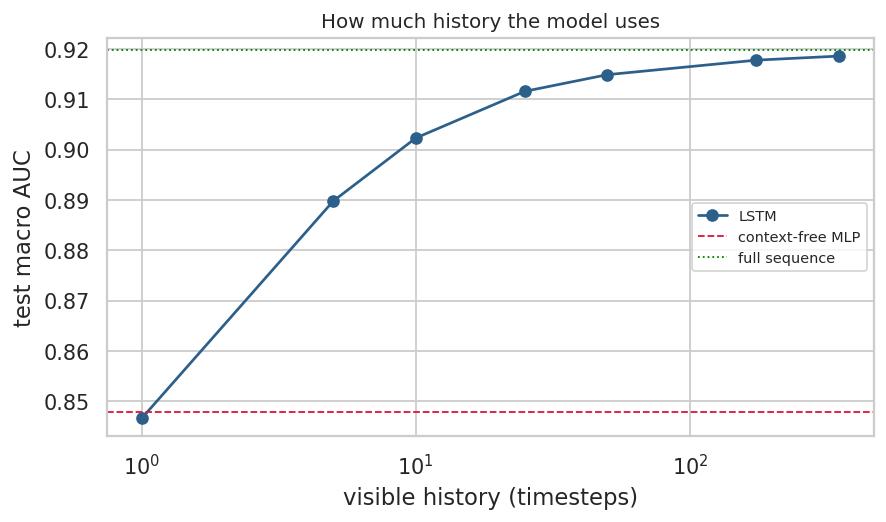

In [18]:
print("\n" + "=" * 74)
print("HOW MUCH HISTORY DOES THE MODEL USE?")
print("=" * 74)
print(f"{'reference':<24}{'MLP capacity-matched':<26}{auc_m:>8.4f}")
print(f"{'reference':<24}{'LSTM full sequence':<26}{auc_l:>8.4f}")
print("-" * 74)
span = auc_l - auc_m
for W in WINDOWS:
    frac = (results[W] - auc_m) / span if span else float('nan')
    bar = '#' * max(0, int(38 * max(frac, 0)))
    print(f"  window {W:>3}  AUC {results[W]:.4f}   {frac:>6.1%} of the gap  {bar}")
print("=" * 74)

reached = [W for W in WINDOWS if (results[W] - auc_m) / span >= 0.90]
if reached:
    print(f"  90% of the sequence advantage is available within {min(reached)} timesteps.")
    print(f"  Deployment implication: a rolling buffer of ~{min(reached)} recent")
    print(f"  attempts suffices; the full student record is unnecessary.")
else:
    print("  The advantage keeps growing with window size -- longer-range")
    print("  dependencies are contributing after all.")

plt.figure(figsize=(7, 4.2))
plt.plot(WINDOWS, [results[W] for W in WINDOWS], 'o-', color='#2c5f8a', label='LSTM')
plt.axhline(auc_m, color='crimson', ls='--', lw=1, label='context-free MLP')
plt.axhline(auc_l, color='green', ls=':', lw=1, label='full sequence')
plt.xscale('log'); plt.xlabel('visible history (timesteps)')
plt.ylabel('test macro AUC'); plt.title('How much history the model uses', fontsize=11)
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('stage2_window_ablation.png', dpi=200, bbox_inches='tight')
plt.show()

## 7 · Training

Masked binary cross-entropy: loss is computed per category per timestep, then
zeroed wherever no label exists, then averaged over labeled positions only. Padded
and unlabeled timesteps still flow through the LSTM as context — they simply do
not contribute gradient.

In [10]:
def masked_bce(logits, y, mask, pos_weight):
    loss = nn.functional.binary_cross_entropy_with_logits(
        logits, y, pos_weight=pos_weight, reduction='none')      # B,T,C
    loss = loss.mean(-1) * mask                                   # B,T
    denom = mask.sum().clamp(min=1.0)
    return loss.sum() / denom


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    tot, n = 0.0, 0
    P, T = [], []
    for kc, num, y, m in loader:
        kc, num, y, m = kc.to(DEVICE), num.to(DEVICE), y.to(DEVICE), m.to(DEVICE)
        logits = model(kc, num)
        tot += masked_bce(logits, y, m, pos_weight).item() * m.sum().item()
        n += m.sum().item()
        sel = m.bool()
        if sel.any():
            P.append(torch.sigmoid(logits)[sel].cpu().numpy())
            T.append(y[sel].cpu().numpy())
    if not P:                       # no labeled timesteps in this split
        return tot / max(n, 1), np.zeros((0, N_CAT)), np.zeros((0, N_CAT))
    return tot / max(n, 1), np.concatenate(P), np.concatenate(T)


def macro_auc(P, T):
    """Returns (macro average, per-category list aligned to category_names).

    A category absent or constant in this split gets NaN rather than being
    skipped -- skipping would shift every later index and silently mislabel
    the per-category report.
    """
    from sklearn.metrics import roc_auc_score
    per = []
    for i in range(T.shape[1] if len(T) else N_CAT):
        if len(T) and 0 < T[:, i].sum() < len(T):
            per.append(float(roc_auc_score(T[:, i], P[:, i])))
        else:
            per.append(float('nan'))
    valid = [a for a in per if a == a]
    return (float(np.mean(valid)) if valid else float('nan')), per


def train(model, name):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    hist = {'train': [], 'val': [], 'val_auc': []}
    best, best_state, bad = float('inf'), None, 0

    for ep in range(1, EPOCHS + 1):
        model.train(); run, n = 0.0, 0
        for kc, num, y, m in dl_tr:
            kc, num, y, m = kc.to(DEVICE), num.to(DEVICE), y.to(DEVICE), m.to(DEVICE)
            opt.zero_grad()
            loss = masked_bce(model(kc, num), y, m, pos_weight)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()
            run += loss.item() * m.sum().item(); n += m.sum().item()

        tr_loss = run / max(n, 1)
        va_loss, P, T = evaluate(model, dl_va)
        auc, _ = macro_auc(P, T)
        hist['train'].append(tr_loss); hist['val'].append(va_loss); hist['val_auc'].append(auc)
        print(f"  [{name}] epoch {ep:>3}  train {tr_loss:.4f}  val {va_loss:.4f}  "
              f"val macro-AUC {auc:.4f}")

        if va_loss < best - 1e-5:
            best, best_state, bad = va_loss, {k: v.detach().clone()
                                              for k, v in model.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= PATIENCE:
                print(f"  [{name}] early stop at epoch {ep}")
                break

    if best_state:
        model.load_state_dict(best_state)
    return model, hist

In [11]:
print("Training LSTM")
lstm, h_lstm = train(MisconceptionLSTM(len(kc_vocab), len(FEATS), N_CAT), "lstm")

print("\nTraining context-free baseline")
base, h_base = train(ContextFreeMLP(len(kc_vocab), len(FEATS), N_CAT), "base")

Training LSTM
  [lstm] epoch   1  train 0.9927  val 0.9035  val macro-AUC 0.7485
  [lstm] epoch   2  train 0.8582  val 0.7972  val macro-AUC 0.8149
  [lstm] epoch   3  train 0.7827  val 0.7380  val macro-AUC 0.8434
  [lstm] epoch   4  train 0.7372  val 0.7009  val macro-AUC 0.8595
  [lstm] epoch   5  train 0.7048  val 0.6711  val macro-AUC 0.8712
  [lstm] epoch   6  train 0.6795  val 0.6509  val macro-AUC 0.8784
  [lstm] epoch   7  train 0.6572  val 0.6318  val macro-AUC 0.8863
  [lstm] epoch   8  train 0.6417  val 0.6175  val macro-AUC 0.8910
  [lstm] epoch   9  train 0.6275  val 0.6050  val macro-AUC 0.8958
  [lstm] epoch  10  train 0.6150  val 0.5948  val macro-AUC 0.8990
  [lstm] epoch  11  train 0.6049  val 0.5866  val macro-AUC 0.9016
  [lstm] epoch  12  train 0.5948  val 0.5804  val macro-AUC 0.9042
  [lstm] epoch  13  train 0.5859  val 0.5724  val macro-AUC 0.9063
  [lstm] epoch  14  train 0.5789  val 0.5689  val macro-AUC 0.9077
  [lstm] epoch  15  train 0.5719  val 0.5623  va

## 8 · Does sequence context help?

In [12]:
lstm_loss, P_l, T_l = evaluate(lstm, dl_te)
base_loss, P_b, T_b = evaluate(base, dl_te)
auc_l, per_l = macro_auc(P_l, T_l)
auc_b, per_b = macro_auc(P_b, T_b)

print("=" * 70)
print("TEST SET — LSTM vs CONTEXT-FREE BASELINE")
print("=" * 70)
print(f"{'':<24}{'LSTM':>12}{'baseline':>12}{'delta':>10}")
print("-" * 70)
print(f"{'masked BCE loss':<24}{lstm_loss:>12.4f}{base_loss:>12.4f}{base_loss-lstm_loss:>+10.4f}")
print(f"{'macro AUC':<24}{auc_l:>12.4f}{auc_b:>12.4f}{auc_l-auc_b:>+10.4f}")
print("-" * 70)
if auc_l == auc_l and auc_b == auc_b:
    if auc_l > auc_b + 0.01:
        print("  Sequence context improves per-interaction prediction.")
        print("  This is the hypothesis, supported.")
    elif abs(auc_l - auc_b) <= 0.01:
        print("  No meaningful difference. On this data the sequence adds nothing")
        print("  beyond the current interaction — a substantive negative result.")
    else:
        print("  The baseline wins. Either the LSTM is undertrained or the sequence")
        print("  genuinely carries no additional signal.")
else:
    print("  AUC undefined — too few labeled test timesteps. Re-run with more labels.")

print(f"\n{'Category':<36}{'LSTM AUC':>10}{'base AUC':>10}")
print("-" * 58)
for i, cname in enumerate(category_names):
    a = per_l[i] if i < len(per_l) else float('nan')
    b = per_b[i] if i < len(per_b) else float('nan')
    fa = f"{a:>10.3f}" if a == a else f"{'n/a':>10}"
    fb = f"{b:>10.3f}" if b == b else f"{'n/a':>10}"
    print(f"{cname[:34]:<36}{fa}{fb}")
print("\n(n/a = category absent or constant in the test split)")

TEST SET — LSTM vs CONTEXT-FREE BASELINE
                                LSTM    baseline     delta
----------------------------------------------------------------------
masked BCE loss               0.5343      0.7091   +0.1748
macro AUC                     0.9198      0.8474   +0.0724
----------------------------------------------------------------------
  Sequence context improves per-interaction prediction.
  This is the hypothesis, supported.

Category                              LSTM AUC  base AUC
----------------------------------------------------------
Appearance-Based Spatial Reasoning       0.985     0.964
Conceptual Meaning Error                 0.890     0.795
Corrupted Procedure Execution            0.877     0.789
Faulty Fact or Formula Recall            0.905     0.828
Invalid Rule Generalisation              0.909     0.823
Representation Misreading                0.957     0.896
Task Interpretation & Monitoring         0.894     0.807
Terminology & Notation Confusio

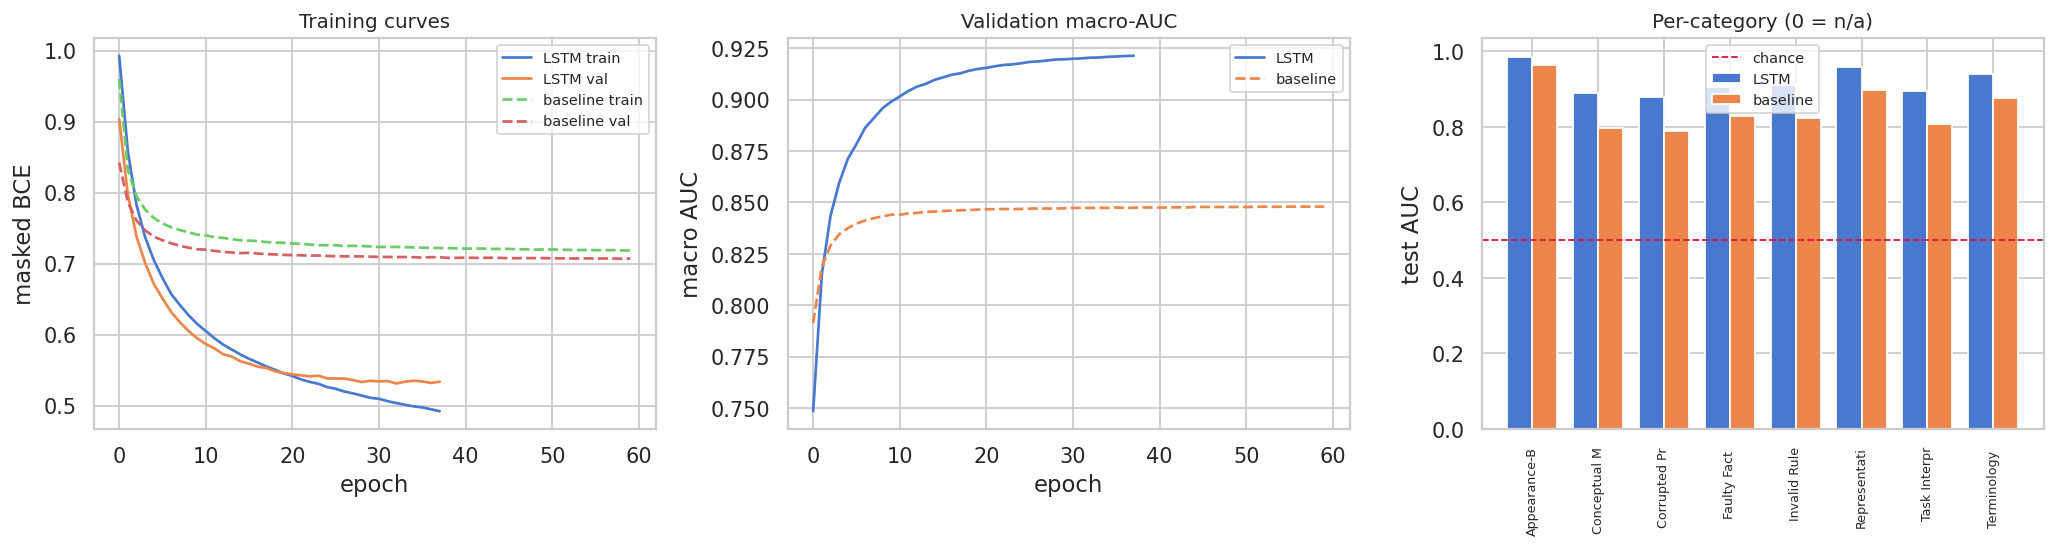

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].plot(h_lstm['train'], label='LSTM train')
axes[0].plot(h_lstm['val'], label='LSTM val')
axes[0].plot(h_base['train'], '--', label='baseline train')
axes[0].plot(h_base['val'], '--', label='baseline val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('masked BCE')
axes[0].set_title('Training curves', fontsize=11); axes[0].legend(fontsize=8)

axes[1].plot(h_lstm['val_auc'], label='LSTM')
axes[1].plot(h_base['val_auc'], '--', label='baseline')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('macro AUC')
axes[1].set_title('Validation macro-AUC', fontsize=11); axes[1].legend(fontsize=8)

w = 0.38; xs = np.arange(len(category_names))
pl = np.array([per_l[i] if i < len(per_l) else np.nan for i in range(len(category_names))])
pb = np.array([per_b[i] if i < len(per_b) else np.nan for i in range(len(category_names))])
axes[2].bar(xs - w/2, np.nan_to_num(pl), w, label='LSTM')
axes[2].bar(xs + w/2, np.nan_to_num(pb), w, label='baseline')
axes[2].axhline(0.5, color='crimson', ls='--', lw=1, label='chance')
axes[2].set_xticks(xs); axes[2].set_xticklabels([c[:12] for c in category_names],
                                                rotation=90, fontsize=7)
axes[2].set_ylabel('test AUC'); axes[2].set_title('Per-category (0 = n/a)', fontsize=11)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('stage2_lstm_vs_baseline.png', dpi=200, bbox_inches='tight')
plt.show()

## 9 · Save

In [14]:
torch.save({'model': lstm.state_dict(),
            'kc_vocab': kc_vocab, 'categories': category_names,
            'feats': FEATS,
            'config': {'MAX_LEN': MAX_LEN, 'KC_EMB': KC_EMB, 'HIDDEN': HIDDEN,
                       'LAYERS': LAYERS, 'DROPOUT': DROPOUT}},
           'stage2_lstm.pt')


def _f(x):
    """NaN -> None so the JSON stays valid."""
    return None if x != x else float(x)


summary = {
    'generated_utc': time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime()),
    'label_source': LABEL_PATH,
    'n_labeled_pairs': len(pair_labels),
    'n_students': int(len(users)),
    'split': {'train': int(len(tr)), 'val': int(len(va)), 'test': int(len(te))},
    'labeled_timestep_share': float(M_lab.sum() / M_pad.sum()),
    'lstm': {'params': n_params(lstm), 'test_loss': lstm_loss,
             'test_macro_auc': _f(auc_l)},
    'baseline': {'params': n_params(base), 'test_loss': base_loss,
                 'test_macro_auc': _f(auc_b)},
    'per_category_auc': {
        c: {'lstm': _f(per_l[i]) if i < len(per_l) else None,
            'baseline': _f(per_b[i]) if i < len(per_b) else None}
        for i, c in enumerate(category_names)
    },
    'config': {'MAX_LEN': MAX_LEN, 'HIDDEN': HIDDEN, 'LAYERS': LAYERS,
               'DROPOUT': DROPOUT, 'LR': LR, 'BATCH': BATCH, 'EPOCHS': EPOCHS},
}

with open('stage2_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Saved stage2_lstm.pt, stage2_results.json, stage2_lstm_vs_baseline.png")
print(json.dumps({k: v for k, v in summary.items() if k != 'per_category_auc'}, indent=2))

Saved stage2_lstm.pt, stage2_results.json, stage2_lstm_vs_baseline.png
{
  "generated_utc": "2026-08-08T16:41:45Z",
  "label_source": "misconception_labels_v1.json",
  "n_labeled_pairs": 20585,
  "n_students": 5000,
  "split": {
    "train": 3500,
    "val": 750,
    "test": 750
  },
  "labeled_timestep_share": 0.22741715610027313,
  "lstm": {
    "params": 224104,
    "test_loss": 0.534296242745632,
    "test_macro_auc": 0.9197581549698554
  },
  "baseline": {
    "params": 27496,
    "test_loss": 0.70908928670717,
    "test_macro_auc": 0.847362138284141
  },
  "config": {
    "MAX_LEN": 350,
    "HIDDEN": 128,
    "LAYERS": 2,
    "DROPOUT": 0.2,
    "LR": 0.001,
    "BATCH": 32,
    "EPOCHS": 60
  }
}


---

## For the Methodology section (Assignment 5.1)

Everything the rubric asks for is above:

- **Model type** — LSTM, trained from scratch, 8 sigmoid outputs for multi-label
  per-interaction classification
- **Architecture** — Section 6: KC embedding (32), 2 LSTM layers, hidden 128,
  dropout 0.2, linear head
- **Loss** — masked binary cross-entropy with per-category `pos_weight`; Section
  5.2 gives the weights and why they come from labeled timesteps
- **Training procedure** — Section 5.1 (70/15/15 split by student, never by
  interaction), Section 7 (Adam, lr 1e-3, batch 32, gradient clipping, early
  stopping on validation loss)
- **Optimization thoughts** — below

Do not report performance numbers in the methods section; those belong in Results.

### Optimization directions for Module 6

- Hidden size and depth: 128×2 is untuned
- Sequence handling: fixed 350-step window versus packed variable-length
- Problem-text embeddings as an additional feature, deliberately excluded here
- `pos_weight` clipping range, currently [0.1, 20]
- Whether unlabeled timesteps should be masked or given an explicit "unknown"
  target
- Learning-rate schedule; currently constant

---

*02 taxonomy · 03 single-label pilot · 04 multi-label validation · 05 full
labeling · 06 model.*